# Furniture + Room Style Embeddings

This notebook keeps the first version simple:

1. Generate embeddings for two datasets:
   - furniture images
   - room style / inspiration images
2. Save them into separate Chroma collections in Chroma Cloud.
3. Embed a user image or text prompt.
4. Retrieve the closest room style images first.
5. Let the user pick more images, average those embeddings, and then query furniture matches.

The same multimodal embedding model is used for images and text so everything lands in one shared vector space.

In [3]:
# If needed, install dependencies inside the notebook.
# Uncomment if your environment does not already have them.
!pip install -q chromadb sentence-transformers pillow numpy tqdm


In [4]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Iterable

import chromadb
import numpy as np
from PIL import Image, ImageFile
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
np.set_printoptions(suppress=True, precision=4)


In [5]:
# Configuration

IS_KAGGLE = Path("/kaggle/input").exists()
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

EMBEDDING_MODEL_NAME = os.getenv("EMBEDDING_MODEL_NAME", "sentence-transformers/clip-ViT-B-32")
CHROMA_MODE = os.getenv("CHROMA_MODE", "local" if IS_KAGGLE else "cloud").strip().lower()

CHROMA_API_KEY = os.getenv("CHROMA_API_KEY", "")
CHROMA_TENANT = os.getenv("CHROMA_TENANT", "")
CHROMA_DATABASE = os.getenv("CHROMA_DATABASE", "")
CHROMA_HOST = os.getenv("CHROMA_HOST", "")
CHROMA_PORT = int(os.getenv("CHROMA_PORT", "443"))
CHROMA_ENABLE_SSL = os.getenv("CHROMA_ENABLE_SSL", "true").strip().lower() in {"1", "true", "yes", "y", "on"}

FURNITURE_COLLECTION_NAME = os.getenv("FURNITURE_COLLECTION_NAME", "furniture_images")
ROOM_COLLECTION_NAME = os.getenv("ROOM_COLLECTION_NAME", "room_style_images")

# Point these at your two datasets.
# On Kaggle, prefer directories under /kaggle/input/<dataset-name>/...
FURNITURE_DIR = Path(os.getenv("FURNITURE_DIR", "/kaggle/input/datasets/oortdatahub/furniture-dataset-for-multi-angle-ai-training" if IS_KAGGLE else "./data/furniture"))
ROOM_STYLE_DIR = Path(os.getenv("ROOM_STYLE_DIR", "/kaggle/input/datasets/stepanyarullin/interior-design-styles" if IS_KAGGLE else "./data/room_styles"))
# If using local Chroma in Kaggle, store the DB in working storage.
CHROMA_LOCAL_PATH = Path(os.getenv("CHROMA_PATH", "/kaggle/working/chroma" if IS_KAGGLE else ".chroma"))

SUPPORTED_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


In [6]:
# Model + Chroma client

model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

if CHROMA_MODE == "local":
    client = chromadb.PersistentClient(path=str(CHROMA_LOCAL_PATH))
else:
    cloud_kwargs: dict[str, object] = {}
    if CHROMA_API_KEY:
        cloud_kwargs["api_key"] = CHROMA_API_KEY
    if CHROMA_TENANT:
        cloud_kwargs["tenant"] = CHROMA_TENANT
    if CHROMA_DATABASE:
        cloud_kwargs["database"] = CHROMA_DATABASE
    if CHROMA_HOST:
        cloud_kwargs["cloud_host"] = CHROMA_HOST
        cloud_kwargs["cloud_port"] = CHROMA_PORT
        cloud_kwargs["enable_ssl"] = CHROMA_ENABLE_SSL
    client = chromadb.CloudClient(**cloud_kwargs)

furniture_collection = client.get_or_create_collection(
    name=FURNITURE_COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"},
)
room_collection = client.get_or_create_collection(
    name=ROOM_COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"},
)

print("Kaggle:", IS_KAGGLE)
print("Device:", DEVICE)
print("Model:", EMBEDDING_MODEL_NAME)
print("Furniture collection:", FURNITURE_COLLECTION_NAME)
print("Room collection:", ROOM_COLLECTION_NAME)


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Kaggle: True
Device: cuda
Model: sentence-transformers/clip-ViT-B-32
Furniture collection: furniture_images
Room collection: room_style_images


In [7]:
def iter_image_files(root_dir: Path) -> list[Path]:
    if not root_dir.exists():
        return []
    files: list[Path] = []
    for path in root_dir.rglob("*"):
        if path.is_file() and path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS:
            files.append(path)
    return sorted(files)


def load_image(path: Path) -> Image.Image:
    try:
        return Image.open(path).convert("RGB")
    except OSError:
        # Some Kaggle images are truncated or corrupted; skip them gracefully.
        return None


def l2_normalize(vector: np.ndarray) -> np.ndarray:
    vector = vector.astype(np.float32)
    norm = float(np.linalg.norm(vector))
    if norm == 0.0:
        return vector
    return vector / norm


def embed_text(text: str) -> list[float]:
    vector = model.encode([text], normalize_embeddings=True, show_progress_bar=False)[0]
    return np.asarray(vector, dtype=np.float32).tolist()


def embed_image(image: Image.Image) -> list[float]:
    vector = model.encode([image], normalize_embeddings=True, show_progress_bar=False)[0]
    return np.asarray(vector, dtype=np.float32).tolist()


def average_vectors(vectors: Iterable[list[float]]) -> list[float]:
    vectors = list(vectors)
    if not vectors:
        raise ValueError("Cannot average an empty vector list.")
    arr = np.asarray(vectors, dtype=np.float32)
    mean = arr.mean(axis=0)
    return l2_normalize(mean).tolist()


def make_id(prefix: str, path: Path) -> str:
    return f"{prefix}:{path.as_posix()}"


In [8]:
def ingest_image_folder(
    *,
    root_dir: Path,
    collection,
    record_type: str,
    batch_size: int = 16,
) -> int:
    image_paths = iter_image_files(root_dir)
    if not image_paths:
        print(f"No images found in {root_dir}")
        return 0

    upserted = 0
    batch_ids: list[str] = []
    batch_docs: list[str] = []
    batch_meta: list[dict[str, object]] = []
    batch_embeddings: list[list[float]] = []

    for path in tqdm(image_paths, desc=f"Embedding {record_type}"):
        image = load_image(path)
        if image is None:
            continue
        embedding = embed_image(image)

        batch_ids.append(make_id(record_type, path))
        batch_docs.append(path.name)
        batch_meta.append(
            {
                "record_type": record_type,
                "file_name": path.name,
                "file_path": str(path),
                "folder": str(path.parent),
            }
        )
        batch_embeddings.append(embedding)

        if len(batch_ids) >= batch_size:
            collection.upsert(
                ids=batch_ids,
                documents=batch_docs,
                metadatas=batch_meta,
                embeddings=batch_embeddings,
            )
            upserted += len(batch_ids)
            batch_ids, batch_docs, batch_meta, batch_embeddings = [], [], [], []

    if batch_ids:
        collection.upsert(
            ids=batch_ids,
            documents=batch_docs,
            metadatas=batch_meta,
            embeddings=batch_embeddings,
        )
        upserted += len(batch_ids)

    return upserted


furniture_count = ingest_image_folder(
    root_dir=FURNITURE_DIR,
    collection=furniture_collection,
    record_type="furniture",
)

room_count = ingest_image_folder(
    root_dir=ROOM_STYLE_DIR,
    collection=room_collection,
    record_type="room_style",
)

print({"furniture_count": furniture_count, "room_count": room_count})


Embedding furniture:   0%|          | 0/10364 [00:00<?, ?it/s]

Embedding room_style:   0%|          | 0/18605 [00:00<?, ?it/s]

{'furniture_count': 10364, 'room_count': 18605}


In [9]:
def query_collection(collection, query_vector: list[float], top_k: int = 10) -> dict:
    return collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        include=["documents", "metadatas", "distances"],
    )


def format_matches(result: dict) -> list[dict[str, object]]:
    matches: list[dict[str, object]] = []
    ids = result.get("ids", [[]])[0]
    docs = result.get("documents", [[]])[0]
    metas = result.get("metadatas", [[]])[0]
    distances = result.get("distances", [[]])[0]

    for item_id, doc, meta, distance in zip(ids, docs, metas, distances):
        matches.append(
            {
                "id": item_id,
                "document": doc,
                "metadata": meta,
                "distance": float(distance),
                "similarity": round(1.0 - float(distance), 4),
            }
        )
    return matches


def get_query_vector(*, text: str | None = None, image_path: str | Path | None = None) -> list[float]:
    vectors: list[list[float]] = []
    if text:
        vectors.append(embed_text(text))
    if image_path:
        vectors.append(embed_image(load_image(Path(image_path))))
    if not vectors:
        raise ValueError("Provide either text or image_path, or both.")
    return average_vectors(vectors)


## Suggested user flow

1. User uploads a room image or types a room description.
2. We create a query embedding.
3. We search the `room_style_images` collection.
4. The user selects some of the returned images they like.
5. We average those selected image embeddings.
6. We query `furniture_images` to get product recommendations.

In [14]:
from matplotlib import pyplot as plt

def show_image_grid(image_paths, titles=None, cols=4, figsize=(16, 12)):
    image_paths = list(image_paths)
    if not image_paths:
        print("No images to display.")
        return

    rows = (len(image_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= len(image_paths):
            continue

        path = Path(image_paths[i])
        try:
            img = Image.open(path).convert("RGB")
            ax.imshow(img)
            title = titles[i] if titles and i < len(titles) else path.name
            ax.set_title(title[:40], fontsize=9)
        except Exception as e:
            ax.set_title(f"Error: {path.name}", fontsize=9)
            ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)

    plt.tight_layout()
    plt.show()

Top room-style matches:
1. victorian_142.jpg | similarity=0.3551
2. eclectic_769.jpg | similarity=0.3244
3. eclectic_285.jpg | similarity=0.3204
4. modern_208.jpg | similarity=0.3181
5. contemporary_599.jpg | similarity=0.317
6. industrial_323.jpg | similarity=0.3158
7. mid-century-modern_148.jpg | similarity=0.3156
8. rustic_977.jpg | similarity=0.3155


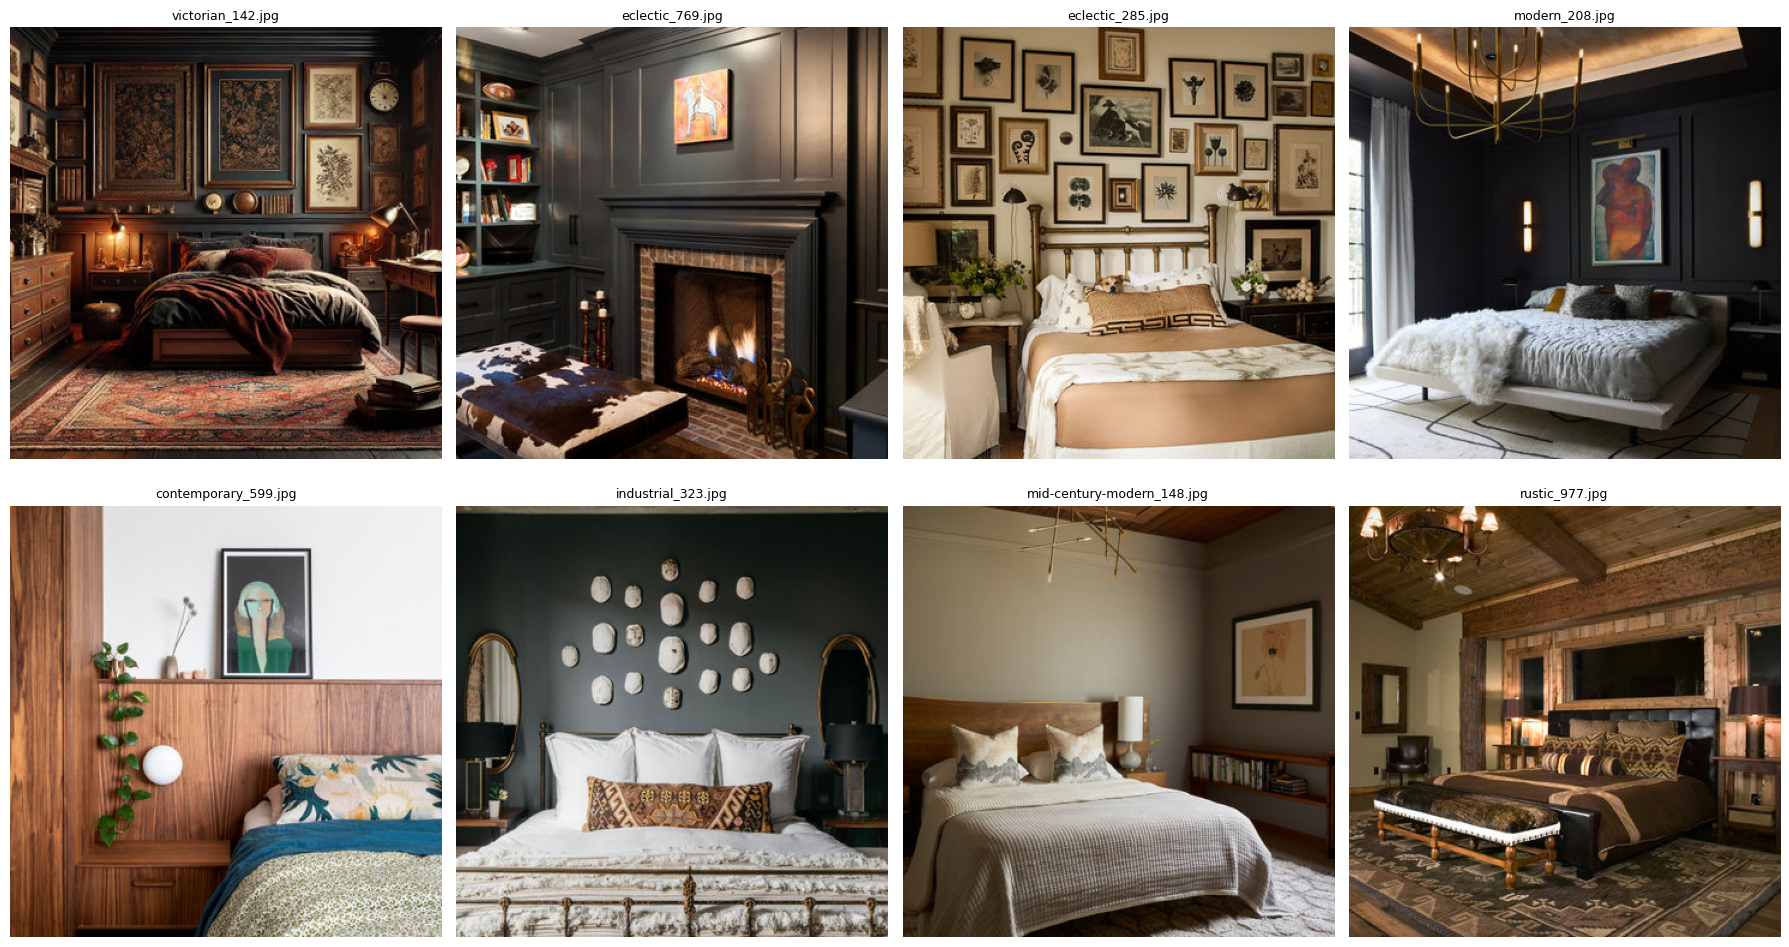


Top furniture matches:
1. f4267fed-dfbf-4c8a-afb9-72762b15262b.png | similarity=0.8579
2. 72b01d69-ad53-4ace-b3a2-45b56a3fc5f6.jpg | similarity=0.8567
3. 48b043d1-f1af-4db1-aa40-2667893863a2.png | similarity=0.8557
4. 2afacc8e-f385-4bf7-9b8c-9f8dd5894d5c.jpg | similarity=0.8522
5. d8e54826-6d4e-4ed1-8c99-01d876d02090.jpg | similarity=0.8485
6. ebcb0dbc-620a-4c26-9f1a-625379618ab7.jpg | similarity=0.8485
7. c6ec3e80-cf5a-49ac-83bd-603dac20d2a2.jpg | similarity=0.8485
8. 42bb9bb5-053d-453e-bd93-20df11b86c99.jpg | similarity=0.8484


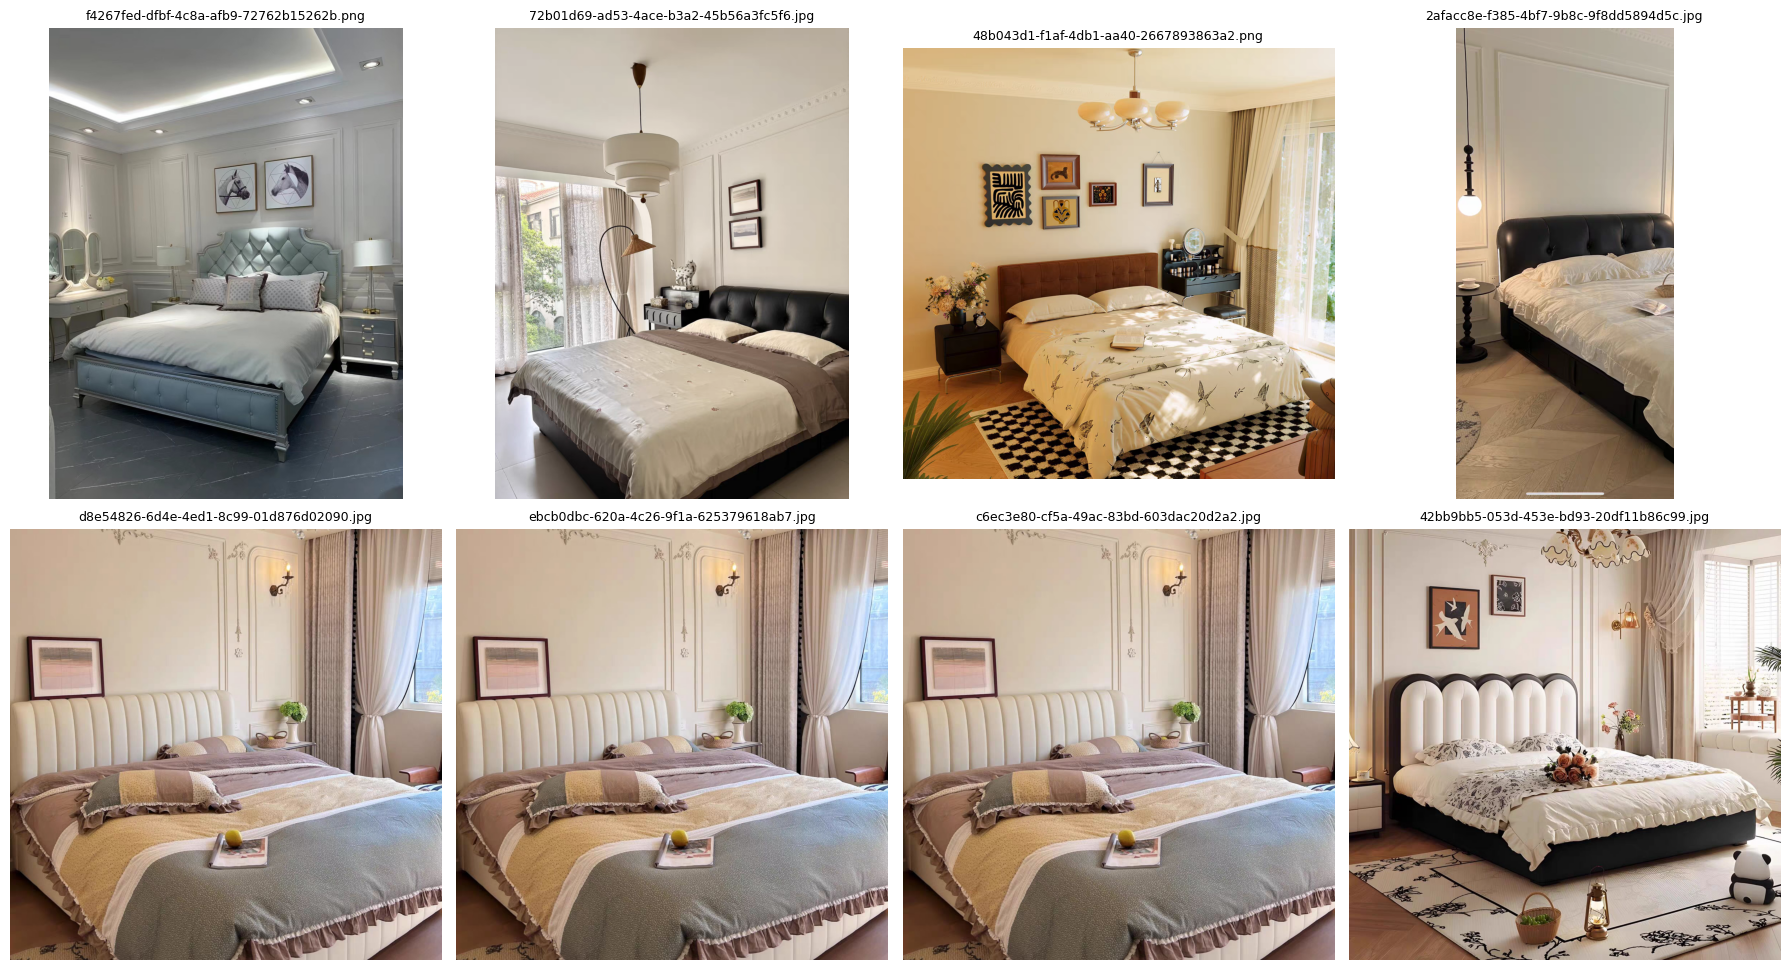

In [15]:
# 1) Embed a user prompt or uploaded image and search room-style matches
# Replace this with either text or an image path.

user_text = "cozy dark academia bedroom with warm wood, brass accents, and layered textures"
user_image_path = None  # e.g. "/kaggle/input/.../my_room.jpg"

if user_image_path:
    query_vector = get_query_vector(image_path=user_image_path)
else:
    query_vector = get_query_vector(text=user_text)

room_results = query_collection(room_collection, query_vector, top_k=8)
room_matches = format_matches(room_results)

print("Top room-style matches:")
for i, match in enumerate(room_matches, start=1):
    print(f"{i}. {match['metadata'].get('file_name', match['id'])} | similarity={match['similarity']}")

room_paths = [m["metadata"]["file_path"] for m in room_matches if m.get("metadata") and m["metadata"].get("file_path")]
show_image_grid(room_paths, cols=4, figsize=(18, 10))


# 2) Simulate user selecting a few liked room images, average their embeddings,
#    then search the furniture collection.

liked_indices = [0, 1, 2]  # change these based on what the user likes
liked_room_paths = [room_matches[i]["metadata"]["file_path"] for i in liked_indices if i < len(room_matches)]

if liked_room_paths:
    liked_vectors = [embed_image(load_image(Path(path))) for path in liked_room_paths if load_image(Path(path)) is not None]
    taste_vector = average_vectors(liked_vectors)

    furniture_results = query_collection(furniture_collection, taste_vector, top_k=8)
    furniture_matches = format_matches(furniture_results)

    print("\nTop furniture matches:")
    for i, match in enumerate(furniture_matches, start=1):
        print(f"{i}. {match['metadata'].get('file_name', match['id'])} | similarity={match['similarity']}")

    furniture_paths = [m["metadata"]["file_path"] for m in furniture_matches if m.get("metadata") and m["metadata"].get("file_path")]
    show_image_grid(furniture_paths, cols=4, figsize=(18, 10))
else:
    print("Select a few room images first before querying furniture.")